# Confusion Matrix

A **confusion matrix** is a table used to evaluate the performance of a classification model. It summarizes the outcomes of predictions by comparing them with the actual values.

The matrix is typically structured as a 2x2 table for binary classification, but can be extended to multi-class problems.

For binary classification, it consists of:

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------- | ---------------------- | ---------------------- |
| **Actual Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual Negative** | False Positive (FP)    | True Negative (TN)     |

### Definitions:

* **True Positive (TP):** Correctly predicted positive cases.
* **False Positive (FP):** Incorrectly predicted positive cases (actual is negative).
* **True Negative (TN):** Correctly predicted negative cases.
* **False Negative (FN):** Incorrectly predicted negative cases (actual is positive).

### Purpose:

The confusion matrix provides detailed insight into:

* Where the model is making correct and incorrect predictions.
* The types of errors (false positives vs. false negatives).

It can also be used as the basis for calculating other performance metrics such as:

* Accuracy = (TP + TN) / (TP + TN + FP + FN)
* Precision = TP / (TP + FP)
* Recall (Sensitivity) = TP / (TP + FN)
* F1 Score = 2 × (Precision × Recall) / (Precision + Recall)


In [34]:

import random
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Models
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# Dataviz
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
import seaborn as sns
import matplotlib.colors as mcolors



In [ ]:
from confusion_matrix import create_confusion_matrix

# Dataset and Modeling

Since this notebooks is focused primarily on the different ways a confusion matrix can be created, we will use a very simple classification dataset for illustration purposes only.

In [35]:

# --- Dataset Creation ---
n_features = 10
X, y = make_classification(n_samples=1000, n_features=n_features, n_informative=4, flip_y=0.05, weights=[0.5, 0.5],random_state=42)
y = y.reshape(-1, 1)
feature_names = [f'Feature {i+1}' for i in range(n_features)]
target_name = ['Target']
columns = feature_names + target_name
df = pd.DataFrame(np.concatenate([X, y], axis=1), columns=columns)

df_train, df_test = train_test_split(df, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
X_train_df, X_test_df = df_train[feature_names], df_test[feature_names]
y_train_df, y_test_df = df_train[target_name], df_test[target_name]


def augment_dataset_location_random(df, location_list, weights=None):
    if isinstance(weights, type(None)):
        df['Location'] = np.random.choice(location_list, size=len(df), p=weights)
        return df
    df['Location'] = np.random.choice(location_list, size=len(df))
    return df

# Location Augmentation
weights = [0.2, 0.25, 0.1, 0.15, 0.2, 0.1]
location_list = ['Chicago', 'New York', 'Boston', 'Miami', 'Los Angeles', 'Stanford']
df = augment_dataset_location_random(df, location_list, weights=weights)

df.head(5)


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Target,Location
0,-0.536590,-3.381416,-0.115171,-1.445070,-0.139984,-0.032793,2.542592,0.885035,-0.628010,-0.332492,0.0,Stanford
1,0.904227,-0.429253,-1.145370,-0.375738,0.801761,-1.160577,1.646145,-0.319551,-0.926977,-1.583125,0.0,Stanford
2,-1.347800,0.236290,-1.375063,-0.316318,-1.348198,-1.381007,0.414781,-0.927678,-2.009327,-0.114016,0.0,Boston
3,-1.798322,-0.161506,-0.280239,-0.384569,1.264620,0.560717,-0.035181,-0.503880,-1.413293,-0.967843,0.0,Los Angeles
4,-1.240801,-0.472518,-0.721987,0.207866,0.841734,-1.106712,-1.474363,0.741224,1.124957,0.056152,1.0,Stanford


In [36]:
lr = LogisticRegression()
lr.fit(X_train_df, y_train_df)

c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



LogisticRegression()

# Confusion Matrix Implementation

In [ ]:
# Moved to confusion_matrix.py script

dataset_dict = {
    "Data":
    {
        "x": df[feature_names],
        "y": df[target_name],
        "y_pred": lr.predict(df[feature_names]),
        "y_prob": lr.predict_proba(df[feature_names]),
    }
}


## Confusion Matrix as a Pandas DataFrame

In [ ]:
create_confusion_matrix(
    dataset_dict,
    fmt_table=False
)

,Predicted Negative,Predicted Positive,Dataset Label
Actual Negative,367 (36.70%),135 (13.50%),Data
Actual Positive,172 (17.20%),326 (32.60%),Data


## Confusion Matrix as a stylized HTML table

In [ ]:
create_confusion_matrix(
    dataset_dict,
    fmt_table=True
)

,Actual,Predicted Negative,Predicted Positive,Dataset Label
0,Actual Negative,True Negative367 (36.7%),False Positive135 (13.5%),Data
1,Actual Positive,False Negative172 (17.2%),True Positive326 (32.6%),Data


## Confusion Matrix as a Matplotlib Image

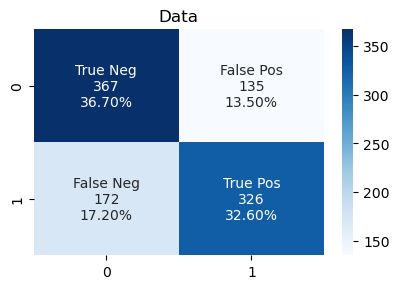

In [ ]:

create_confusion_matrix(
    dataset_dict,
    output_type='image'
)

## Confusion Matrix as a Plotly Table

In [ ]:

create_confusion_matrix(
    dataset_dict,
    output_type='plotly_table'
)


# Application: Analyzing data partitions

Here, we will simulate how this implementation can be used to analyze different data sets (Train/Test), clusters of data (as random samples) and categorical partitions of the data (using the Location column).

In [42]:

dataset_dict = {
    "Train":
    {
        "x": df_train[feature_names],
        "y": df_train[target_name],
        "y_pred": lr.predict(df_train[feature_names]),
        "y_prob": lr.predict_proba(df_train[feature_names]),
    },
    "Test":
    {
        "x": df_test[feature_names],
        "y": df_test[target_name],
        "y_pred": lr.predict(df_test[feature_names]),
        "y_prob": lr.predict_proba(df_test[feature_names]),
    },
}

create_confusion_matrix(dataset_dict, fmt_table=True)


,Actual,Predicted Negative,Predicted Positive,Dataset Label
0,Actual Negative,True Negative274 (36.53%),False Positive109 (14.53%),Train
1,Actual Positive,False Negative123 (16.4%),True Positive244 (32.53%),Train
2,Actual Negative,True Negative93 (37.2%),False Positive26 (10.4%),Test
3,Actual Positive,False Negative49 (19.6%),True Positive82 (32.8%),Test


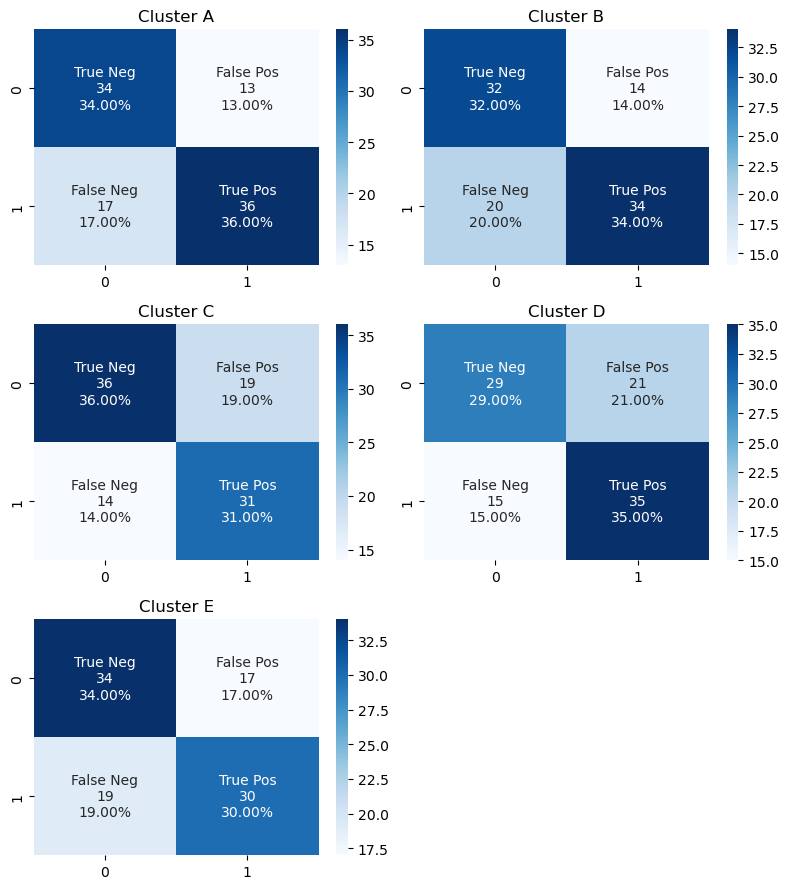

In [43]:

dataset_dict = {
    "Cluster A": {"y": df[target_name].sample(100, random_state=42), "y_pred": lr.predict(df[feature_names].sample(100, random_state=42))},
    "Cluster B": {"y": df[target_name].sample(100, random_state=43), "y_pred": lr.predict(df[feature_names].sample(100, random_state=43))},
    "Cluster C": {"y": df[target_name].sample(100, random_state=44), "y_pred": lr.predict(df[feature_names].sample(100, random_state=44))},
    "Cluster D": {"y": df[target_name].sample(100, random_state=45), "y_pred": lr.predict(df[feature_names].sample(100, random_state=45))},
    "Cluster E": {"y": df[target_name].sample(100, random_state=46), "y_pred": lr.predict(df[feature_names].sample(100, random_state=46))},
}

create_confusion_matrix(dataset_dict, output_type='image', max_cols=2)

In [44]:

dataset_dict = {
    location:
        {"y": df[df['Location'] == location][target_name],
         "y_pred": lr.predict(df[df['Location'] == location][feature_names]),}
        for location in df['Location'].unique()
}

create_confusion_matrix(dataset_dict, output_type='plotly_table')
